# Chapter 1 — Introduction

An overview of sustainable finance's recent growth and the regulatory
landscape around it (Roncalli, *Handbook of Sustainable Finance*): assets
under management by sustainable investing strategy, PRI signatory growth,
and the expansion of ESG-related regulation worldwide. Where a topic has
been revisited with a newer data vintage over the years, this notebook
uses the most recent one available (the 2024 PRI signatory and regulation
datasets) rather than reproducing every earlier pass.

Everything here only needs `pandas`/`numpy`/`matplotlib`. The two source
spreadsheets (`pri_regulation_2024.xlsx`, `pri_signatory_2024.xlsx`) are
read directly with `pandas.read_excel`.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

DATA_DIR = "../../data"


## 1. Growth of sustainable investing strategies

Assets under management by sustainable investing strategy, from the
Global Sustainable Investment Review, 2014–2022.

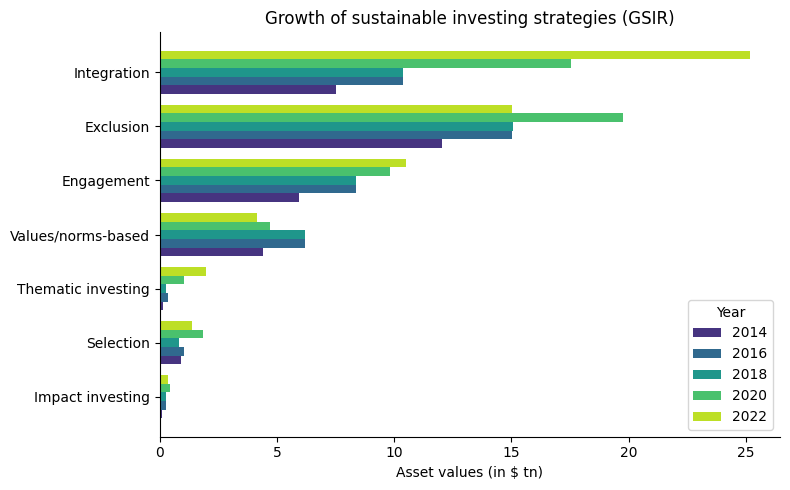

In [2]:
years = [2014, 2016, 2018, 2020, 2022]
strategies = [
    "Impact investing", "Selection", "Thematic investing",
    "Values/norms-based", "Engagement", "Exclusion", "Integration",
]
# rows = strategies (in the order above), columns = years (in $ bn)
aum = np.array([
    [101,   248,   248,   444,    352],
    [890,  1030,   818,  1842,   1384],
    [137,   331,   276,  1018,   1948],
    [4385, 6210,  6195,  4679,   4140],
    [5919, 8365,  8385,  9835,  10504],
    [12046,15023, 15064, 19771, 15030],
    [7527, 10369, 10353, 17544, 25195],
]) / 1000  # -> $ tn

fig, ax = plt.subplots(figsize=(8, 5))
y_pos = np.arange(len(strategies))
bar_h = 0.8 / len(years)
colors = plt.cm.viridis(np.linspace(0.15, 0.9, len(years)))

for i, (year, color) in enumerate(zip(years, colors)):
    ax.barh(y_pos + i * bar_h, aum[:, i], height=bar_h, color=color, label=str(year))

ax.set_yticks(y_pos + bar_h * (len(years) - 1) / 2)
ax.set_yticklabels(strategies)
ax.set_xlabel("Asset values (in $ tn)")
ax.set_title("Growth of sustainable investing strategies (GSIR)")
ax.legend(title="Year", loc="lower right")
plt.tight_layout()
plt.show()


## 2. PRI signatories and assets under management

PRI annual report figures, 2006–2021.

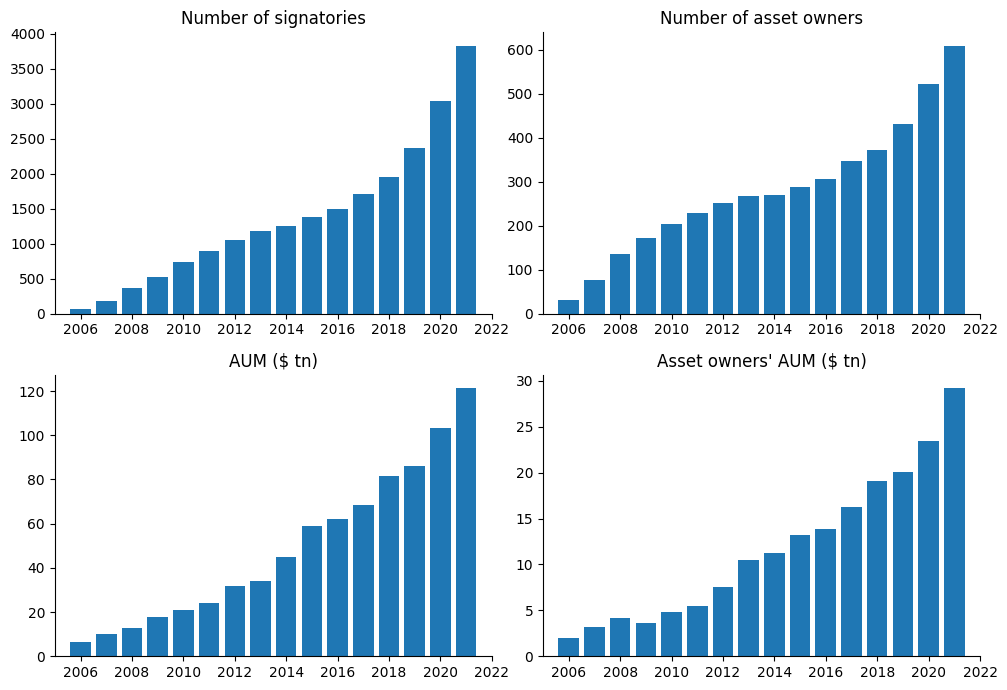

In [3]:
pri_growth = pd.DataFrame({
    "year":    [2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021],
    "aum_ao":  [2.0,3.2,4.2,3.6,4.8,5.5,7.6,10.5,11.2,13.2,13.9,16.3,19.1,20.1,23.5,29.2],
    "nb_ao":   [32,77,135,172,203,229,251,268,270,288,307,346,373,432,521,609],
    "aum_all": [6.5,10,13,18,21,24,32,34,45,59,62,68.4,81.7,86.3,103.4,121.3],
    "nb_all":  [63,185,361,523,734,890,1050,1186,1251,1384,1501,1714,1951,2372,3038,3826],
}).set_index("year")

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
panels = [
    ("nb_all",  "Number of signatories",    axes[0, 0]),
    ("nb_ao",   "Number of asset owners",   axes[0, 1]),
    ("aum_all", "AUM ($ tn)",               axes[1, 0]),
    ("aum_ao",  "Asset owners' AUM ($ tn)", axes[1, 1]),
]
for col, title, ax in panels:
    ax.bar(pri_growth.index, pri_growth[col])
    ax.set_title(title)
    ax.set_xlim(2005, 2022)
plt.tight_layout()
plt.show()


## 3. PRI signatories by region

Number of new signatories per year by region, 2015–2023, read directly
from the PRI signatory list (`pri_signatory_2024.xlsx`).

In [4]:
signatories = pd.read_excel(f"{DATA_DIR}/pri_signatory_2024.xlsx", sheet_name=0)
signatories = signatories.rename(columns={
    "Account Name": "name", "Signatory Category": "type",
    "Signature Date": "date", "HQ Country": "country",
})
signatories["date"] = pd.to_datetime(signatories["date"])
signatories["year"] = signatories["date"].dt.year

country_region = pd.read_excel(f"{DATA_DIR}/pri_signatory_2024.xlsx", sheet_name=1)
country_region = country_region.rename(columns={"Country": "country", "Region": "region"})
signatories = signatories.merge(country_region, on="country", how="left")

years = range(2015, 2024)
by_region_year = (
    signatories[signatories["year"].isin(years)]
    .pivot_table(index="region", columns="year", values="name", aggfunc="count", fill_value=0)
)
by_region_year["Total (2015-2023)"] = by_region_year.sum(axis=1)
by_region_year.loc["Total"] = by_region_year.sum()
by_region_year


year,2015,2016,2017,2018,2019,2020,2021,2022,2023,Total (2015-2023)
region,,,,,,,,,,
Africa,2,3,6,3,11,11,23,19,12,90
Asia,9,21,25,31,49,57,122,107,79,500
Australasia,6,8,18,11,21,23,45,28,19,179
Europe,67,94,129,188,293,433,532,374,221,2331
Latin America,1,1,8,12,26,59,66,49,20,242
Middle East,2,0,1,1,2,8,10,8,9,41
North America,38,41,66,85,137,187,260,191,105,1110
Total,125,168,253,331,539,778,1058,776,465,4493


## 4. Growth in ESG regulation

Cumulative number of ESG-related regulations issued worldwide, 1990–2023.

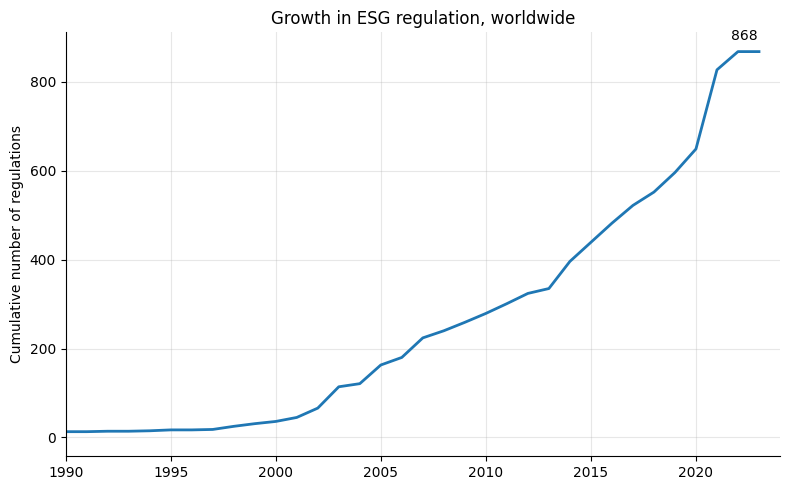

In [5]:
regulations = pd.read_excel(f"{DATA_DIR}/pri_regulation_2024.xlsx", sheet_name="Public RD", header=1)
regulations = regulations.rename(columns={
    "Issuance year": "issuance_year", "Region": "region", "Country": "country",
    "Mandatory (including comply or explain)": "mandatory", "Voluntary": "voluntary",
    "Government (Ministries, Regulators)": "issuer_government",
    "Industry (Stock exchanges, Industry associations)": "issuer_industry",
    "International Organisations (OECD, UN, ILO etc.)": "issuer_international",
    "Investment Managers": "applies_investment_managers",
    "Financial Service providers": "applies_financial_services",
    "Corporations": "applies_corporations",
    "Credit Rating Agencies": "applies_cra",
})
regulations = regulations[regulations["issuance_year"].notna()]
regulations["issuance_year"] = regulations["issuance_year"].astype(int)

flag_cols = [
    "issuer_government", "issuer_industry", "issuer_international",
    "Corporate ESG disclosure", "Investor ESG disclosure", "Investor ESG Intergration",
    "Stewardship Code", "Taxonomy", "Sector specific policy",
    "Financial products (green bonds, green labels etc.)", "Other",
    "National Sustainable Finance Strategy",
    "mandatory", "voluntary",
    "applies_investment_managers", "applies_financial_services",
    "applies_corporations", "applies_cra",
]
regulations[flag_cols] = regulations[flag_cols].apply(pd.to_numeric, errors="coerce").fillna(0)

by_year = regulations.groupby("issuance_year").size().reindex(
    range(int(regulations["issuance_year"].min()), 2024), fill_value=0
)
cumulative = by_year.cumsum()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(cumulative.index, cumulative.values, "-", linewidth=2)
ax.set_xlim(1990, 2024)
ax.set_ylabel("Cumulative number of regulations")
ax.set_title("Growth in ESG regulation, worldwide")
ax.annotate(str(int(cumulative.iloc[-1])), (cumulative.index[-1], cumulative.iloc[-1]),
            textcoords="offset points", xytext=(-20, 8))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 5. ESG regulation by region

Same cumulative count, split across the four largest regions.

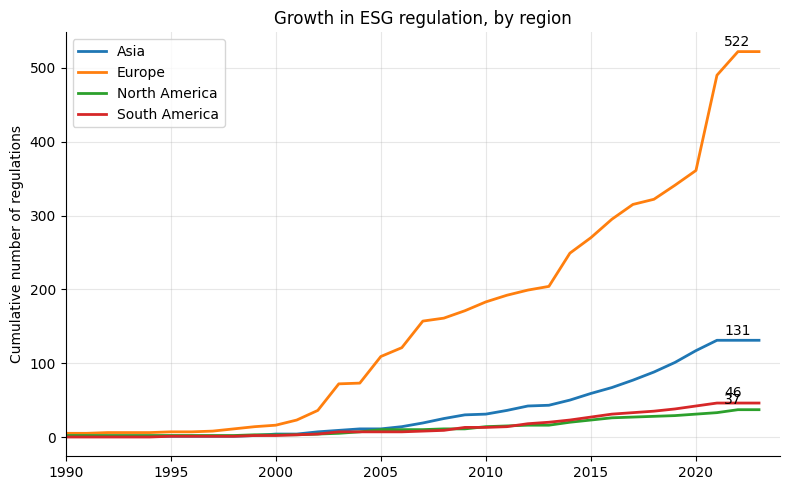

In [6]:
selected_regions = ["Asia", "Europe", "North America", "South America"]
by_region = (
    regulations[regulations["region"].isin(selected_regions)]
    .groupby(["issuance_year", "region"]).size()
    .unstack(fill_value=0)
    .reindex(range(int(regulations["issuance_year"].min()), 2024), fill_value=0)
    .cumsum()
)

fig, ax = plt.subplots(figsize=(8, 5))
for region in selected_regions:
    ax.plot(by_region.index, by_region[region], "-", linewidth=2, label=region)
    ax.annotate(str(int(by_region[region].iloc[-1])),
                (by_region.index[-1], by_region[region].iloc[-1]),
                textcoords="offset points", xytext=(-25, 4))
ax.set_xlim(1990, 2024)
ax.set_ylabel("Cumulative number of regulations")
ax.set_title("Growth in ESG regulation, by region")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 6. Characteristics of ESG regulations

Who issues these regulations, what type they are, whether they're
mandatory or voluntary, who they apply to, and which countries have
issued the most.

In [7]:
n = len(regulations)

def summarize(cols, label):
    counts = regulations[cols].sum()
    counts["Any"] = regulations[cols].any(axis=1).sum()
    out = pd.DataFrame({"count": counts, "pct": 100 * counts / n})
    print(f"--- {label} ---")
    display(out.round(1))

summarize(["issuer_government", "issuer_industry", "issuer_international"], "Who has issued the policy?")

policy_type_cols = [
    "Corporate ESG disclosure", "Investor ESG disclosure", "Investor ESG Intergration",
    "Stewardship Code", "Taxonomy", "Sector specific policy",
    "Financial products (green bonds, green labels etc.)", "Other",
    "National Sustainable Finance Strategy",
]
summarize(policy_type_cols, "What type of policy?")

summarize(["mandatory", "voluntary"], "Voluntary or mandatory?")

applies_to_cols = [
    "applies_investment_managers", "applies_financial_services",
    "applies_corporations", "applies_cra",
]
summarize(applies_to_cols, "Who is it applicable to?")

print("--- Which country? (top 20) ---")
by_country = regulations["country"].str.strip().str.lower().value_counts().head(20)
display(by_country)


--- Who has issued the policy? ---


,count,pct
issuer_government,684.0,78.8
issuer_industry,165.0,19.0
issuer_international,24.0,2.8
Any,868.0,100.0


--- What type of policy? ---


,count,pct
Corporate ESG disclosure,534.0,61.5
Investor ESG disclosure,210.0,24.2
Investor ESG Intergration,176.0,20.3
Stewardship Code,23.0,2.6
Taxonomy,14.0,1.6
Sector specific policy,49.0,5.6
"Financial products (green bonds, green labels etc.)",39.0,4.5
Other,85.0,9.8
National Sustainable Finance Strategy,94.0,10.8
Any,868.0,100.0


--- Voluntary or mandatory? ---


,count,pct
mandatory,580.0,66.8
voluntary,288.0,33.2
Any,868.0,100.0


--- Who is it applicable to? ---


,count,pct
applies_investment_managers,347.0,40.0
applies_financial_services,141.0,16.2
applies_corporations,628.0,72.4
applies_cra,56.0,6.5
Any,769.0,88.6


--- Which country? (top 20) ---


country
china                       49
germany                     31
european union              29
italy                       28
spain                       26
france                      24
united states of america    23
japan                       22
netherlands                 22
united kingdom              20
finland                     20
south africa                19
australia                   18
canada                      18
austria                     17
ireland                     16
sweden                      16
denmark                     16
belgium                     15
romania                     15
Name: count, dtype: int64